
=== 3-way ANOVA (Type II) ===
                              sum_sq   df           F         PR(>F)
C(gender)               3.906012e+06  1.0   90.952071   3.821042e-17
C(age)                  7.004132e+07  4.0  407.730620   1.784824e-79
C(occupation_category)  1.503982e+08  4.0  875.511012  7.576834e-103
C(gender):C(age)        8.611750e+05  4.0    5.013146   8.058844e-04

Sex × Age interaction p = 0.000806  →  YES – the gender gap differs by age.


/var/folders/xf/3h6xnmdj0jg__mms2zt6r6wc0000gn/T/ipykernel_25895/1251152762.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_tbl = (df.groupby(["age", "gender"])["mean_salary"]


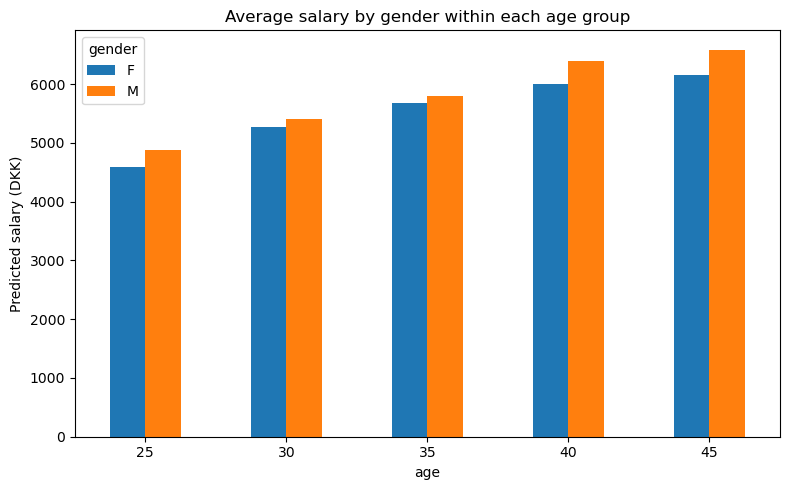

In [2]:
# gender_age_job_anova.py  ------------------------------------------
# Needs: pandas, statsmodels, matplotlib
# -------------------------------------------------------------------
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
import matplotlib.pyplot as plt

CSV = "/Users/vitusthaulow/Downloads/02445 Datasheet.csv"

# 1. Load the four columns we need
cols = ["gender", "age", "occupation_category", "mean_salary"]
df   = pd.read_csv(CSV, usecols=cols)

# 2. Treat grouping variables as factors
for col in ["gender", "age", "occupation_category"]:
    df[col] = df[col].astype("category")

# 3. Three-way ANOVA (Type II)
model = smf.ols("mean_salary ~ C(gender)*C(age)*C(occupation_category)",
                data=df).fit()
anova = sm.stats.anova_lm(model, typ=2)

print("\n=== 3-way ANOVA (Type II) ===")
print(anova.loc[["C(gender)", "C(age)", "C(occupation_category)",
                 "C(gender):C(age)"]])

p = anova.loc["C(gender):C(age)", "PR(>F)"]
msg = "YES – the gender gap differs by age." if p < 0.05 else \
      "No – the gap is roughly constant across ages."
print(f"\nSex × Age interaction p = {p:.3g}  →  {msg}")

# 4. Bar-plot with fixed colours (blue = F, orange = M)
colour_map = {"F": "#1f77b4",   # same blue as before
              "M": "#ff7f0e"}   # same orange

mean_tbl = (df.groupby(["age", "gender"])["mean_salary"]
              .mean()
              .unstack())        # rows = age, cols = gender

ax = mean_tbl.loc[:, ["F", "M"]].plot(
        kind="bar", figsize=(8, 5), rot=0,
        color=[colour_map["F"], colour_map["M"]])

ax.set_ylabel("Predicted salary (DKK)")
ax.set_title("Average salary by gender within each age group")
ax.legend(title="gender")
plt.tight_layout()
plt.show()

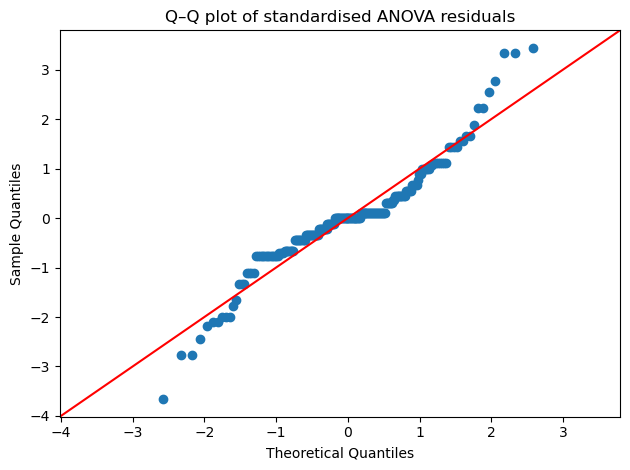

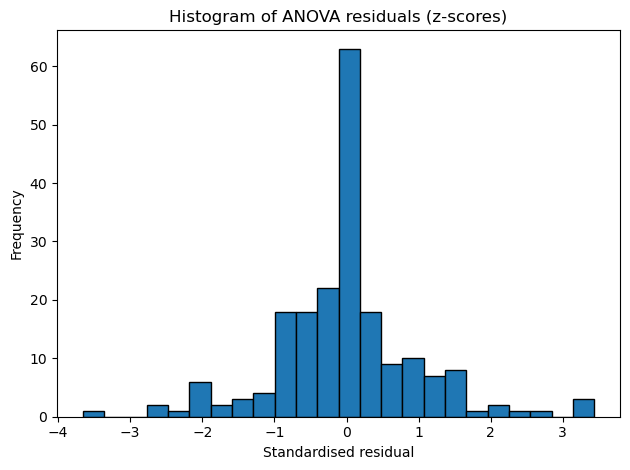


Shapiro–Wilk test: W = 0.935,  p = 8.139e-08
→ Residuals deviate significantly from normality.


In [5]:
# ---------- 3 b. Normality diagnostics  --------------------------------
import scipy.stats as st

# ❶ Get residuals and standardise them
resid     = model.resid
resid_z   = (resid - resid.mean()) / resid.std(ddof=1)   # z-scores

# ❷ Q–Q plot (now properly scaled)
fig, ax = plt.subplots()
sm.qqplot(resid_z, line="45", ax=ax)
ax.set_title("Q–Q plot of standardised ANOVA residuals")
plt.tight_layout()
plt.show()

# ❸ Histogram of the same z-scores
plt.hist(resid_z, bins="auto", edgecolor="k")
plt.xlabel("Standardised residual")
plt.ylabel("Frequency")
plt.title("Histogram of ANOVA residuals (z-scores)")
plt.tight_layout()
plt.show()

# ❹ Shapiro–Wilk test (on raw residuals – scale doesn’t matter for the test)
w, p = st.shapiro(resid)
print(f"\nShapiro–Wilk test: W = {w:.3f},  p = {p:.4g}")
if p > 0.05:
    print("→ No evidence against residual normality.")
else:
    print("→ Residuals deviate significantly from normality.")

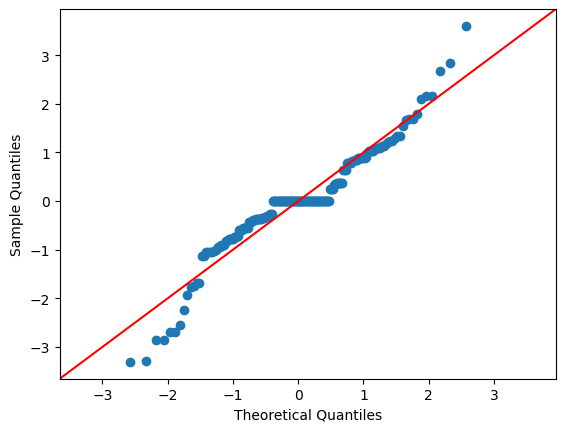

ShapiroResult(statistic=0.9300094982282348, pvalue=3.3820107591809915e-08)


In [8]:
import numpy as np
df['log_salary'] = np.log(df['mean_salary'])

model_log = smf.ols("log_salary ~ C(gender)*C(age)*C(occupation_category)",
                    data=df).fit()

# Normality check on log-scale residuals
resid_z = (model_log.resid - model_log.resid.mean()) / model_log.resid.std(ddof=1)
sm.qqplot(resid_z, line="45"); plt.show()
print(st.shapiro(model_log.resid))


In [14]:
8.139e-08>0.05

False


=== ANOVA ===
                                       sum_sq   df           F        PR(>F)
C(occupation_category)            150398200.0  4.0  265.000779  1.216608e-75
C(gender)                           3906012.5  1.0   27.529488  4.189242e-07
C(occupation_category):C(gender)    1566800.0  4.0    2.760693  2.909410e-02


/var/folders/xf/3h6xnmdj0jg__mms2zt6r6wc0000gn/T/ipykernel_20672/2594320453.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_tbl = (df.groupby(["occupation_category", "gender"])["mean_salary"]


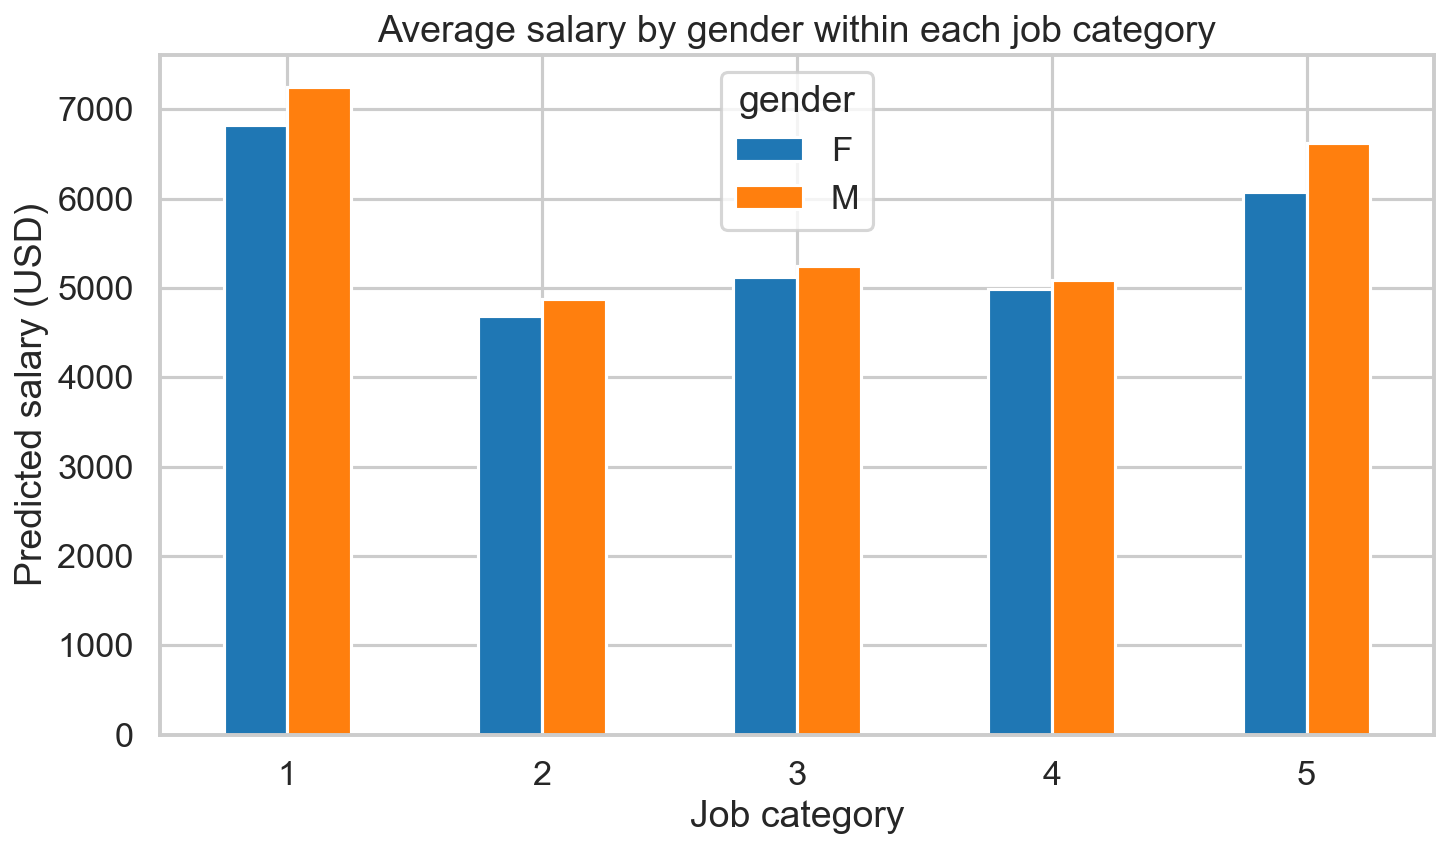

In [2]:
# job_gender_anova.py  ----------------------------------------------
# Checks two things:
#   1) Do the five job categories get different salaries?
#   2) Does the gender gap change from job to job?
# Then draws a bar-chart with the same look-and-feel as the
#   “Average salary by gender within each age group” plot.
# -------------------------------------------------------------------
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

CSV = "/Users/vitusthaulow/Downloads/02445 Datasheet.csv"

# ---------- 1. Load and prep ---------------------------------------
cols = ["gender", "age", "occupation_category", "mean_salary"]
df   = pd.read_csv(CSV, usecols=cols)

for col in ["gender", "age", "occupation_category"]:
    df[col] = df[col].astype("category")

# ---------- 2. ANOVA ------------------------------------------------
model = smf.ols("mean_salary ~ C(occupation_category) * C(gender) + C(age)",
                data=df).fit()
anova = sm.stats.anova_lm(model, typ=2)

print("\n=== ANOVA ===")
print(anova.loc[["C(occupation_category)",
                 "C(gender)",
                 "C(occupation_category):C(gender)"]])

# ---------- 3. Bar-plot (same style as age plot) --------------------
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 150

# Fixed colours: blue = F, orange = M
colour_map = {"F": "#1f77b4", "M": "#ff7f0e"}

mean_tbl = (df.groupby(["occupation_category", "gender"])["mean_salary"]
              .mean()
              .unstack())

ax = mean_tbl.loc[:, ["F", "M"]].plot(
        kind="bar", figsize=(10, 6), rot=0,
        color=[colour_map["F"], colour_map["M"]])

ax.set_xlabel("Job category")
ax.set_ylabel("Predicted salary (USD)")
ax.set_title("Average salary by gender within each job category")
ax.legend(title="gender")

plt.tight_layout()
plt.show()